# Earth Observation 

This notebook implements the full pipeline:

1. Spatial reasoning and filtering
2. Label construction and dataset preparation
3. CNN training and supervised evaluation


## Install dependencies



In [1]:
%pip install geopandas rasterio shapely pyproj leafmap matplotlib seaborn scikit-learn torch torchvision torchmetrics tqdm pillow scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing Libraries & Setup for the project

In [2]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.transform import rowcol
from rasterio.errors import RasterioIOError
from shapely.geometry import box
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchmetrics.classification import MulticlassF1Score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## Dataset Loading

In [3]:
from pathlib import Path

# Paths (updated folder name)
ROOT = Path.cwd()
DATA = ROOT / "Data"
RGB_DIR = DATA / "rgb"
DELHI_NCR = DATA / "delhi_ncr_region.geojson"
DELHI_AIRSHED = DATA / "delhi_airshed.geojson"
LANDCOVER_TIF = DATA / "worldcover_bbox_delhi_ncr_2021.tif"

OUT = ROOT / "outputs"
FIG_DIR = OUT / "figures"
PROC_DIR = OUT / "processed"
MODEL_DIR = OUT / "models"

for p in [OUT, FIG_DIR, PROC_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert RGB_DIR.exists(), f"Missing RGB directory: {RGB_DIR}"
assert DELHI_NCR.exists(), f"Missing NCR file: {DELHI_NCR}"
assert LANDCOVER_TIF.exists(), f"Missing landcover tif: {LANDCOVER_TIF}"

print("Root:", ROOT)
print("Images:", len(list(RGB_DIR.glob("*.png"))))

Root: C:\Users\ASUS\Desktop\IIT_GN\Earth_Observation
Images: 9216


## Spatial reasoning and data filtering

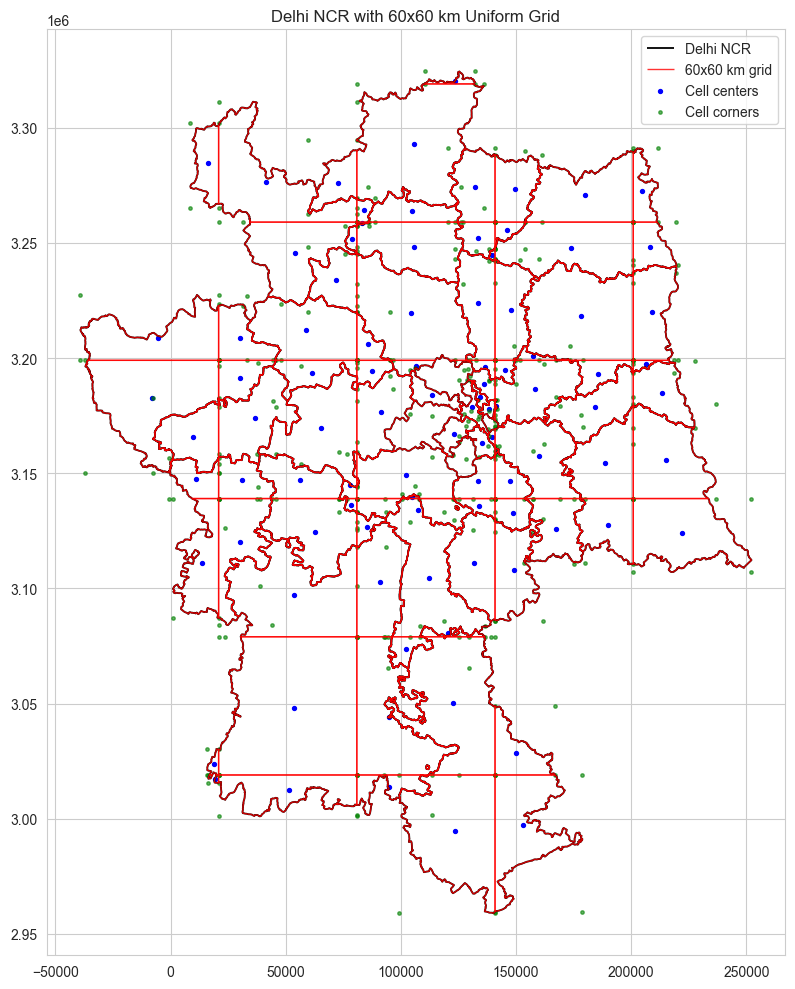

Images before filtering: 9216
Images after filtering : 8015
Saved Q1 outputs to: C:\Users\ASUS\Desktop\IIT_GN\Earth_Observation\outputs\processed


In [4]:
# Q1: Spatial reasoning and data filtering

def parse_lat_lon_from_name(png_path: Path):
    stem = png_path.stem
    lat_s, lon_s = stem.split("_")
    return float(lat_s), float(lon_s)

def build_uniform_grid(gdf_utm, cell_size_m=60000):
    minx, miny, maxx, maxy = gdf_utm.total_bounds
    x_coords = np.arange(minx, maxx + cell_size_m, cell_size_m)
    y_coords = np.arange(miny, maxy + cell_size_m, cell_size_m)

    cells = []
    for x0 in x_coords[:-1]:
        for y0 in y_coords[:-1]:
            x1, y1 = x0 + cell_size_m, y0 + cell_size_m
            cells.append(box(x0, y0, x1, y1))

    grid = gpd.GeoDataFrame({"geometry": cells}, crs=gdf_utm.crs)
    grid = gpd.overlay(grid, gdf_utm[["geometry"]], how="intersection")
    grid = grid[~grid.geometry.is_empty].copy()
    grid["cell_id"] = np.arange(len(grid))
    return grid

# Load shapefiles
ncr = gpd.read_file(DELHI_NCR)
airshed = gpd.read_file(DELHI_AIRSHED) if DELHI_AIRSHED.exists() else None

# Reproject to UTM zone 44N for 60x60 km grid
ncr_utm = ncr.to_crs("EPSG:32644")
grid_utm = build_uniform_grid(ncr_utm, cell_size_m=60000)

# centers and corners of each cell
corner_rows = []
center_rows = []
for _, row in grid_utm.iterrows():
    geom = row.geometry
    minx, miny, maxx, maxy = geom.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    for i, (x, y) in enumerate(corners):
        corner_rows.append({"cell_id": row.cell_id, "corner_id": i, "geometry": gpd.points_from_xy([x], [y])[0]})

    c = geom.centroid
    center_rows.append({"cell_id": row.cell_id, "geometry": c})

corners_gdf = gpd.GeoDataFrame(corner_rows, crs=grid_utm.crs)
centers_gdf = gpd.GeoDataFrame(center_rows, crs=grid_utm.crs)

# Static plot
fig, ax = plt.subplots(figsize=(10, 10))
ncr_utm.boundary.plot(ax=ax, color="black", linewidth=1.3, label="Delhi NCR")
grid_utm.boundary.plot(ax=ax, color="red", linewidth=1, alpha=0.8, label="60x60 km grid")
centers_gdf.plot(ax=ax, color="blue", markersize=8, label="Cell centers")
corners_gdf.plot(ax=ax, color="green", markersize=6, alpha=0.6, label="Cell corners")
ax.set_title("Delhi NCR with 60x60 km Uniform Grid")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "q1_grid_static.png", dpi=200)
plt.show()

# Build image center points from filenames
image_records = []
for p in RGB_DIR.glob("*.png"):
    try:
        lat, lon = parse_lat_lon_from_name(p)
        image_records.append({"image_path": str(p), "filename": p.name, "lat": lat, "lon": lon})
    except Exception:
        pass

img_df = pd.DataFrame(image_records)
img_gdf = gpd.GeoDataFrame(
    img_df,
    geometry=gpd.points_from_xy(img_df["lon"], img_df["lat"]),
    crs="EPSG:4326",
).to_crs(grid_utm.crs)

# Filter points that fall inside any grid cell
union_geom = grid_utm.unary_union
img_gdf["in_grid"] = img_gdf.geometry.within(union_geom)
filtered = img_gdf[img_gdf["in_grid"]].copy()

before_count = len(img_gdf)
after_count = len(filtered)
print(f"Images before filtering: {before_count}")
print(f"Images after filtering : {after_count}")

# Save outputs
img_gdf.to_csv(PROC_DIR / "q1_all_images_points.csv", index=False)
filtered.to_csv(PROC_DIR / "q1_filtered_images_points.csv", index=False)
grid_utm.to_file(PROC_DIR / "q1_grid_utm.geojson", driver="GeoJSON")
centers_gdf.to_file(PROC_DIR / "q1_grid_centers_utm.geojson", driver="GeoJSON")
corners_gdf.to_file(PROC_DIR / "q1_grid_corners_utm.geojson", driver="GeoJSON")

print("Saved Q1 outputs to:", PROC_DIR)

## Satellite basemap overlay (interactive)

In [5]:
# Optional: satellite basemap overlay (interactive)
# If this fails due to missing environment support, skip this cell.
try:
    import leafmap

    grid_wgs84 = grid_utm.to_crs("EPSG:4326")
    centers_wgs84 = centers_gdf.to_crs("EPSG:4326")
    corners_wgs84 = corners_gdf.to_crs("EPSG:4326")

    m = leafmap.Map(center=[28.61, 77.20], zoom=8)
    m.add_basemap("SATELLITE")
    m.add_gdf(grid_wgs84, layer_name="Grid")
    m.add_gdf(centers_wgs84, layer_name="Centers")
    m.add_gdf(corners_wgs84, layer_name="Corners")
    m.to_html(str(FIG_DIR / "q1_satellite_overlay.html"))
    m
except Exception as e:
    print("Basemap cell skipped:", e)

## Label construction and dataset preparation

In [6]:
# Q2: Label construction and dataset preparation

ESA_11_CLASS_MAP = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow and ice",
    80: "Permanent water bodies",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss and lichen",
}

PATCH_SIZE = 128
HALF = PATCH_SIZE // 2
NODATA_SKIP_THRESHOLD = 0.6  # skip patch if >60% no-data


def extract_patch_mode_label(src, lon, lat):
    """
    Extract a 128x128 patch from landcover raster centered at (lon, lat in EPSG:4326)
    and return dominant class with edge-case flags.
    """
    # transform lon/lat -> raster CRS
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    x, y = transformer.transform(lon, lat)

    r, c = rowcol(src.transform, x, y)
    r0, c0 = r - HALF, c - HALF

    # window clipping to raster bounds
    win = Window(c0, r0, PATCH_SIZE, PATCH_SIZE)
    data = src.read(1, window=win, boundless=True, fill_value=src.nodata)

    # no-data handling
    if src.nodata is not None:
        valid_mask = data != src.nodata
    else:
        valid_mask = np.ones_like(data, dtype=bool)

    valid_vals = data[valid_mask]
    nodata_ratio = 1.0 - (valid_vals.size / data.size)

    if valid_vals.size == 0:
        return None, "all_nodata", nodata_ratio

    if nodata_ratio > NODATA_SKIP_THRESHOLD:
        return None, "high_nodata", nodata_ratio

    vals, counts = np.unique(valid_vals, return_counts=True)
    mode_val = vals[np.argmax(counts)]

    if mode_val not in ESA_11_CLASS_MAP:
        return None, f"unknown_class_{int(mode_val)}", nodata_ratio

    return int(mode_val), "ok", nodata_ratio

labeled_rows = []

with rasterio.open(LANDCOVER_TIF) as src:
    for _, row in tqdm(filtered.to_crs("EPSG:4326").iterrows(), total=len(filtered), desc="Labeling"):
        lon, lat = row.geometry.x, row.geometry.y
        mode_cls, status, nodata_ratio = extract_patch_mode_label(src, lon, lat)

        if status != "ok":
            continue

        labeled_rows.append(
            {
                "image_path": row.image_path,
                "filename": row.filename,
                "lat": lat,
                "lon": lon,
                "esa_code": mode_cls,
                "label_name": ESA_11_CLASS_MAP[mode_cls],
                "nodata_ratio": nodata_ratio,
            }
        )

labels_df = pd.DataFrame(labeled_rows)
print("Usable labeled samples:", len(labels_df))
print(labels_df["label_name"].value_counts().head(15))

# 60/40 split random
train_df, test_df = train_test_split(
    labels_df,
    test_size=0.40,
    random_state=SEED,
    shuffle=True,
    stratify=labels_df["label_name"] if labels_df["label_name"].nunique() > 1 else None,
)
train_df = train_df.copy()
test_df = test_df.copy()
train_df["split"] = "train"
test_df["split"] = "test"
final_df = pd.concat([train_df, test_df], ignore_index=True)

final_df.to_csv(PROC_DIR / "q2_labeled_dataset.csv", index=False)
print("Saved:", PROC_DIR / "q2_labeled_dataset.csv")
print(final_df["split"].value_counts())

Labeling: 100%|███████████████████████████████████████████████████████████████████| 8015/8015 [00:49<00:00, 160.71it/s]


Usable labeled samples: 8015
label_name
Cropland                  5474
Built-up                  1778
Tree cover                 341
Shrubland                  247
Grassland                  166
Permanent water bodies       7
Herbaceous wetland           2
Name: count, dtype: int64
Saved: C:\Users\ASUS\Desktop\IIT_GN\Earth_Observation\outputs\processed\q2_labeled_dataset.csv
split
train    4809
test     3206
Name: count, dtype: int64


## Class Distribution Plots

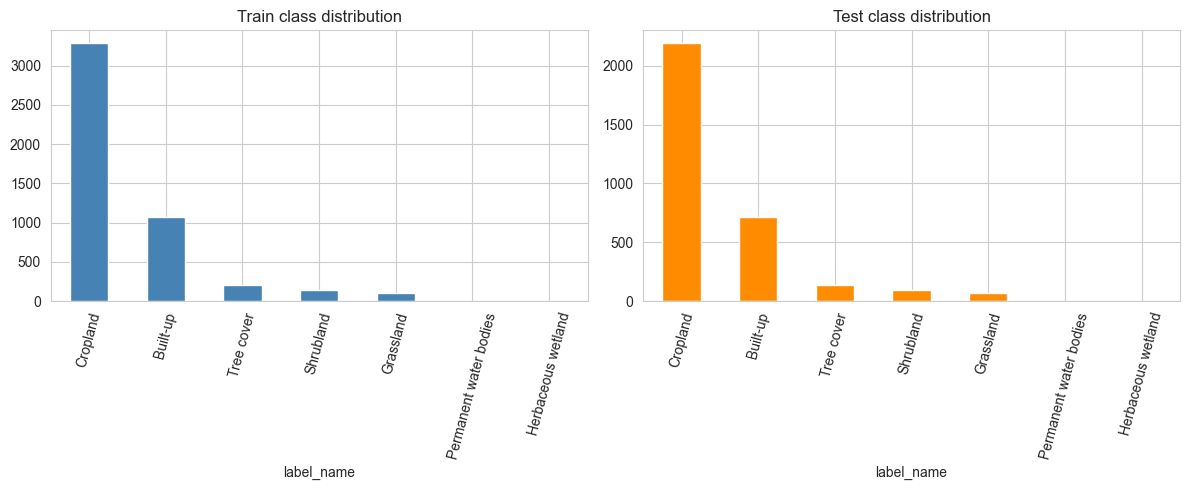

Approx train imbalance ratio (max/min): 3284.00


In [7]:
# Q2: class distribution plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
train_df["label_name"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Train class distribution")
plt.xticks(rotation=75)

plt.subplot(1, 2, 2)
test_df["label_name"].value_counts().plot(kind="bar", color="darkorange")
plt.title("Test class distribution")
plt.xticks(rotation=75)

plt.tight_layout()
plt.savefig(FIG_DIR / "q2_class_distribution.png", dpi=200)
plt.show()

imbalance_ratio = train_df["label_name"].value_counts().max() / max(1, train_df["label_name"].value_counts().min())
print(f"Approx train imbalance ratio (max/min): {imbalance_ratio:.2f}")

## Dataset & Dataloaders

In [8]:
# Q3: dataset + dataloaders
class EOImageDataset(Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        y = self.class_to_idx[row["label_name"]]
        return img, y, row["image_path"], row["label_name"]

classes = sorted(final_df["label_name"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(classes)
print("Classes:", NUM_CLASSES)
print(class_to_idx)

train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = EOImageDataset(train_df, class_to_idx, transform=train_tfms)
test_ds = EOImageDataset(test_df, class_to_idx, transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

print("Train size:", len(train_ds), "| Test size:", len(test_ds))

Classes: 7
{'Built-up': 0, 'Cropland': 1, 'Grassland': 2, 'Herbaceous wetland': 3, 'Permanent water bodies': 4, 'Shrubland': 5, 'Tree cover': 6}
Train size: 4809 | Test size: 3206


## CNN Model Training and supervised evaluation

In [9]:
# Q3: model, training, and custom F1

def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def custom_macro_f1(y_true, y_pred, num_classes):
    f1s = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        f1s.append(f1)
    return float(np.mean(f1s))

model = build_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5  # increase to 10-20 for stronger results
best_f1 = -1

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for x, y, _, _ in tqdm(train_loader, desc=f"Train Epoch {epoch}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y, _, _ in test_loader:
            x = x.to(DEVICE)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(pred.tolist())
            y_true.extend(y.numpy().tolist())

    epoch_f1 = custom_macro_f1(y_true, y_pred, NUM_CLASSES)
    avg_train_loss = train_loss / len(train_ds)
    print(f"Epoch {epoch}/{EPOCHS} | Loss: {avg_train_loss:.4f} | Custom Macro F1: {epoch_f1:.4f}")

    if epoch_f1 > best_f1:
        best_f1 = epoch_f1
        torch.save(model.state_dict(), MODEL_DIR / "q3_resnet18_best.pt")

print("Best custom macro F1:", best_f1)
print("Saved model:", MODEL_DIR / "q3_resnet18_best.pt")

Train Epoch 1: 100%|███████████████████████████████████████████████████████████████████| 76/76 [03:55<00:00,  3.10s/it]


Epoch 1/5 | Loss: 0.4162 | Custom Macro F1: 0.4824


Train Epoch 2: 100%|███████████████████████████████████████████████████████████████████| 76/76 [05:59<00:00,  4.72s/it]


Epoch 2/5 | Loss: 0.2465 | Custom Macro F1: 0.2907


Train Epoch 3: 100%|███████████████████████████████████████████████████████████████████| 76/76 [05:58<00:00,  4.71s/it]


...

Epoch 3/5 | Loss: 0.1900 | Custom Macro F1: 0.3549


Train Epoch 4: 100%|███████████████████████████████████████████████████████████████████| 76/76 [03:47<00:00,  3.00s/it]


Epoch 4/5 | Loss: 0.1693 | Custom Macro F1: 0.4041


Train Epoch 5: 100%|███████████████████████████████████████████████████████████████████| 76/76 [03:39<00:00,  2.89s/it]


Epoch 5/5 | Loss: 0.1473 | Custom Macro F1: 0.4369
Best custom macro F1: 0.5027758284583637
Saved model: C:\Users\ASUS\Desktop\IIT_GN\Earth_Observation\outputs\models\q3_resnet18_best.pt


## Evaluation metrics (Accuracy, Precision, Recall, F1, RMSE, MAE)

In [11]:
# Evaluation metrics (Accuracy, Precision, Recall, F1, RMSE, MAE)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    mean_squared_error,
    mean_absolute_error,
)

acc = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

# NOTE: RMSE/MAE are not standard for classification
# but computed here on class indices if explicitly required.
rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae = mean_absolute_error(y_true, y_pred)

print("Classification Metrics")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision (macro) : {precision_macro:.4f}")
print(f"Recall (macro)    : {recall_macro:.4f}")
print(f"F1 (macro)        : {f1_macro:.4f}")
print(f"Precision (wt)    : {precision_weighted:.4f}")
print(f"Recall (wt)       : {recall_weighted:.4f}")
print(f"F1 (wt)           : {f1_weighted:.4f}")

print(f"RMSE (class idx)  : {rmse:.4f}")
print(f"MAE (class idx)   : {mae:.4f}")

Classification Metrics
Accuracy          : 0.8434
Precision (macro) : 0.4664
Recall (macro)    : 0.4926
F1 (macro)        : 0.4459
Precision (wt)    : 0.8965
Recall (wt)       : 0.8434
F1 (wt)           : 0.8598
RMSE (class idx)  : 1.6402
MAE (class idx)   : 0.5611
